# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> TfLite

In [ ]:
import os
import torch

from src.utils import load_data, process_callbacks
from src.quantization.converters.to_onnx import export_pytorch_to_onnx, export_onnx_to_savedmodel, export_savedmodel_to_tflite
from src.train.knowledge_distillation import train_qat_kd
from src.utils.logging_setup import configure_logging

2025-04-23 16:52:10.772379: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 16:52:10.794299: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 16:52:10.794320: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 16:52:10.795142: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 16:52:10.799563: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-04-23 16:52:11,526 preprocessing.py:17] Train dataset size: 29322
[INFO 2025-04-23 16:52:11,527 preprocessing.py:26] Class distribution for train dataset:
[INFO 2025-04-23 16:52:11,527 preprocessing.py:28]   Class 'Actinic keratoses': 693 samples
[INFO 2025-04-23 16:52:11,527 preprocessing.py:28]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-04-23 16:52:11,527 preprocessing.py:28]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'Chickenpox': 900 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'Cowpox': 792 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'Dermatofibroma': 191 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'HFMD': 1932 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'Healthy': 1368 samples
[INFO 2025-04-23 16:52:11,528 preprocessing.py:28]   Class 'Measles': 660 samples
[INFO 2025-04-23 16:52:11,529 preprocessi

Model prepared using Export Mode QAT.


Train Epoch 1/1: 100%|██████████| 917/917 [03:02<00:00,  5.03it/s, loss=0.8445]
[INFO 2025-04-23 16:55:17,651 knowledge_distillation.py:109] Train Loss: 0.8445
[INFO 2025-04-23 16:55:17,652 knowledge_distillation.py:110] Train Metrics: accuracy: 0.6943, recall: 0.4973, precision: 0.5862, f1-score: 0.5199, auc-score: 0.9415
[INFO 2025-04-23 16:55:17,655 eval.py:150] Starting inference...
Inference Progress: 100%|██████████| 115/115 [00:18<00:00,  6.24it/s]
[INFO 2025-04-23 16:55:36,338 eval.py:178] Inference complete.
/home/jacob-delgado/anaconda3/envs/ECG_tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
[INFO 2025-04-23 16:55:36,369 knowledge_distillation.py:203] Val Loss: 0.7244
[INFO 2025-04-23 16:55:36,369 knowledge_distillatio

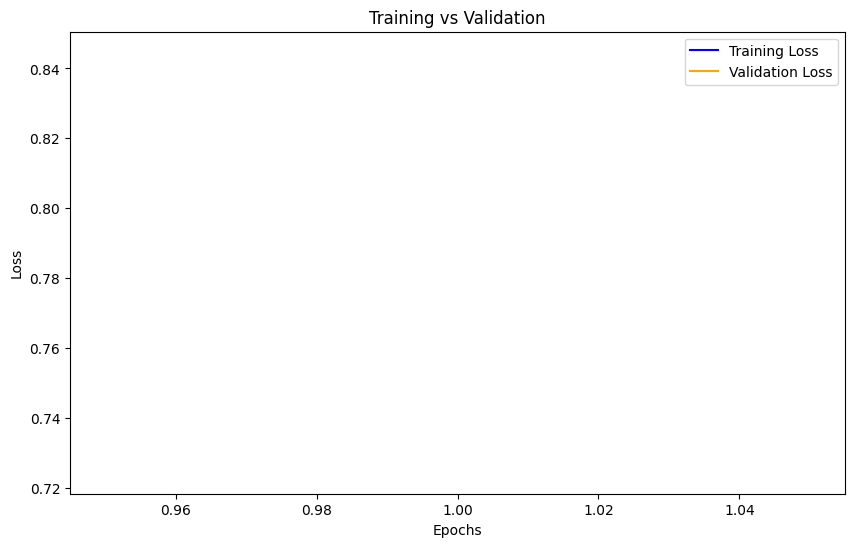

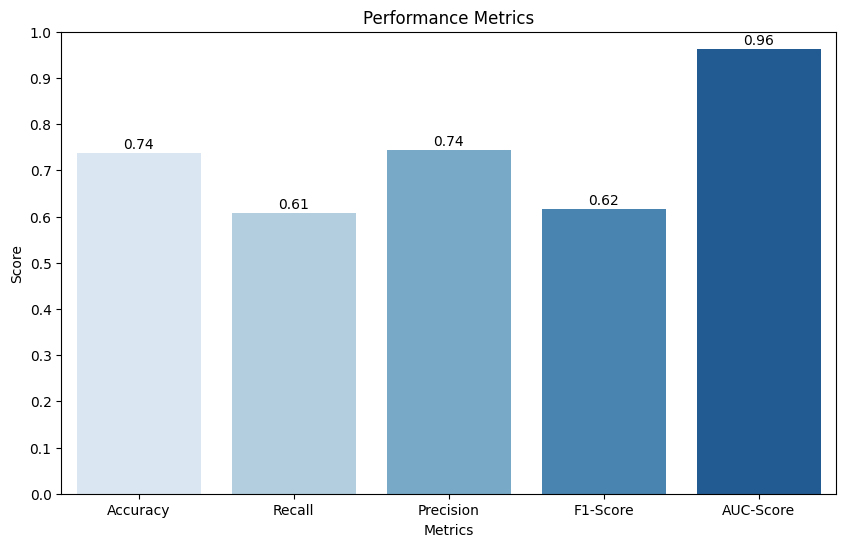

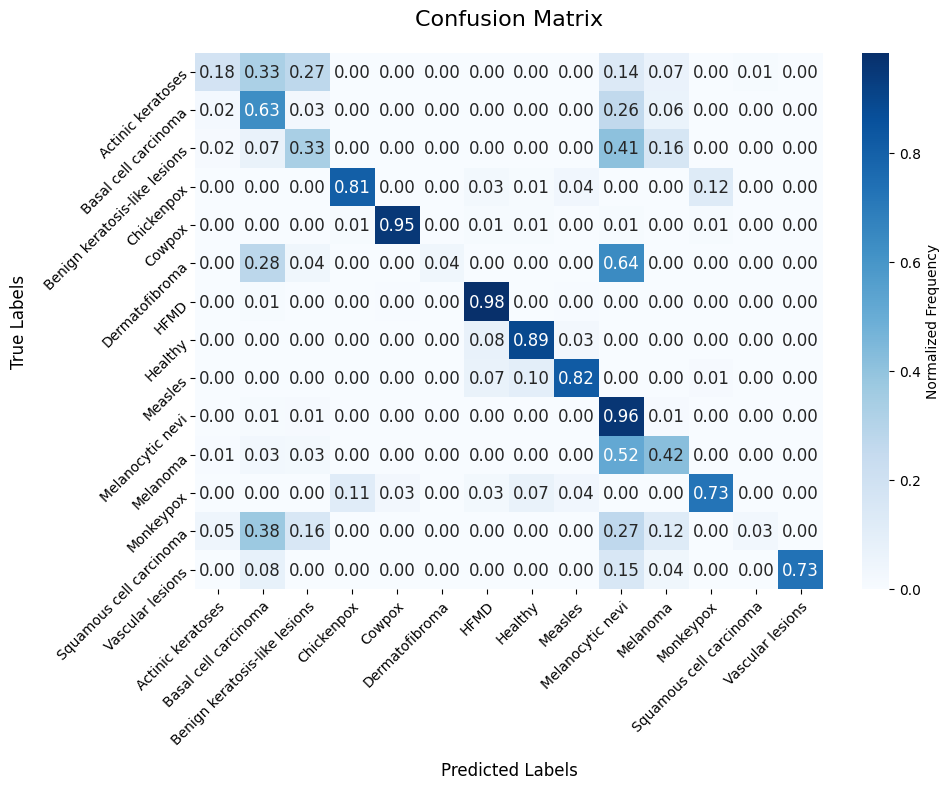

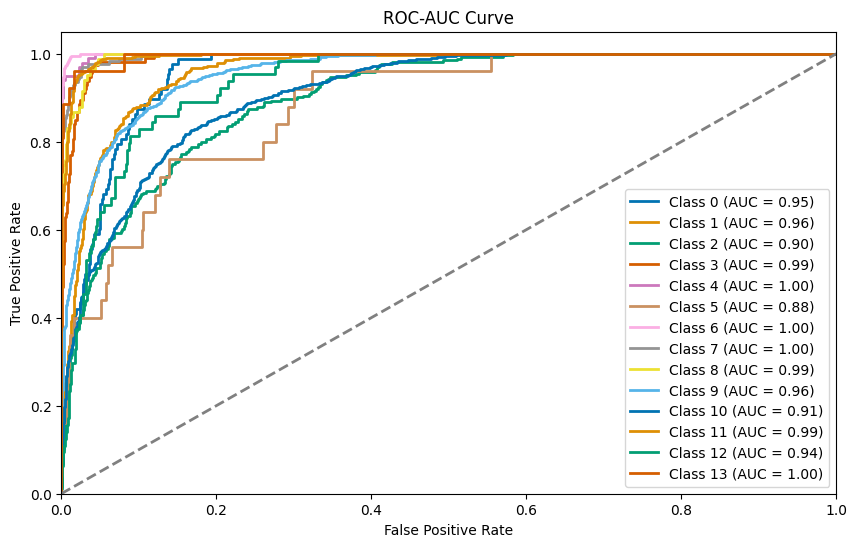

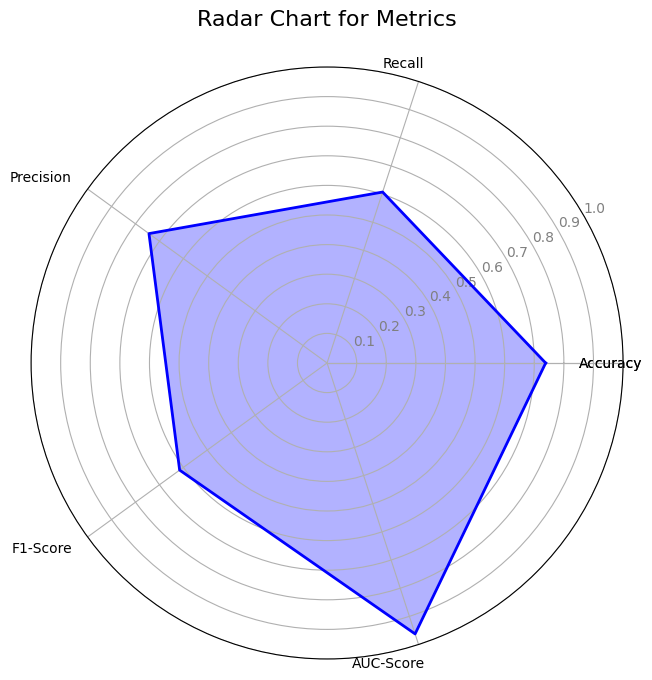

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_qat_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        quant_mode="export",
                                        teacher_model_weights=teacher_model_weights,
                                        device=device,
                                )


### 2. Export to TfLite

In [ ]:
example_inputs = next(iter(dataloaders['train']))[0]
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_pytorch_to_onnx(quantized_student, example_inputs, onnx_path)

In [ ]:
print(os.path.getsize("models/SkinCancer/Quantized/quantized_student_state.pth") / 1e6)